# Notebook 1/3 — Data Preprocessing

**Pipeline**: Heterogeneous RGAT for Source-Code Graph Link Prediction

This notebook covers the full preprocessing pipeline:
1. Load & validate the Django ecosystem JSON graph
2. Schema validation (strict per-type feature checks)
3. **Data quality cleaning** — collapse file nodes, remove empty `__init__` hubs, fix self-loops, cap CALLS degree
4. Exploratory Data Analysis (node/edge statistics, post-cleaning)
5. Sentence-transformer encoding of `embedding_input` strings
6. Build PyG `HeteroData` object with scalar, text, and Leiden features
7. Train/val edge splitting via `RandomLinkSplit`
8. Save all preprocessed artifacts to disk

Artifacts produced here are loaded by **02_training.ipynb**.

## 1. Imports & Setup

In [1]:
# ── Colab Setup ──────────────────────────────────────────────────────
# Mount Google Drive and copy project files to local disk for fast I/O.
# Required uploads in Google Drive under "MSAAI/capstone/":
#   1. django_ecosystem_v1.json  (241 MB)
#   2. rgat_source.zip           (63 KB — contains rgat/ and graph_builder/)

import shutil
from pathlib import Path
from google.colab import drive

drive.mount("/content/drive")

DRIVE_DIR = Path("/content/drive/MyDrive/MSAAI/capstone")
PROJECT_ROOT = Path("/content/rgat_project")
PROJECT_ROOT.mkdir(exist_ok=True)

# Copy JSON dataset
json_src = DRIVE_DIR / "django_ecosystem_v1.json"
json_dst = PROJECT_ROOT / "django_ecosystem_v1.json"
if not json_dst.exists():
    print(f"Copying JSON ({json_src.stat().st_size / 1e6:.0f} MB) ...")
    shutil.copy2(json_src, json_dst)
    print("✓ JSON copied")
else:
    print("✓ JSON already present")

# Unzip source code
zip_src = DRIVE_DIR / "rgat_source.zip"
if not (PROJECT_ROOT / "rgat").exists():
    import zipfile
    print("Extracting source code ...")
    with zipfile.ZipFile(zip_src, "r") as zf:
        zf.extractall(PROJECT_ROOT)
    print("✓ Source code extracted")
else:
    print("✓ Source code already present")

# Create working directories
for d in ["artifacts", "cache", "checkpoints"]:
    (PROJECT_ROOT / d).mkdir(exist_ok=True)

print(f"\nPROJECT_ROOT = {PROJECT_ROOT}")
!ls {PROJECT_ROOT}

Mounted at /content/drive
Copying JSON (245 MB) ...
✓ JSON copied
Extracting source code ...
✓ Source code extracted

PROJECT_ROOT = /content/rgat_project
artifacts  checkpoints		     graph_builder  requirements.txt
cache	   django_ecosystem_v1.json  notebooks	    rgat


In [2]:
# Force re-extract source code from updated zip
import shutil, zipfile
from pathlib import Path
PROJECT_ROOT = Path("/content/rgat_project")
DRIVE_DIR = Path("/content/drive/MyDrive/MSAAI/capstone")
zip_src = DRIVE_DIR / "rgat_source.zip"
for pkg in ["rgat", "graph_builder"]:
    old = PROJECT_ROOT / pkg
    if old.exists():
        shutil.rmtree(old)
with zipfile.ZipFile(zip_src, "r") as zf:
    zf.extractall(PROJECT_ROOT)
print("✓ Source code re-extracted from updated zip")

✓ Source code re-extracted from updated zip


In [3]:
%pip install torch_geometric sentence-transformers igraph leidenalg --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 81.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 151.2 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 111.2 MB/s eta 0:00:00


In [4]:
import sys, os, json, time, warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch_geometric.data import HeteroData

# PROJECT_ROOT was set in the Colab setup cell above
# Add it to sys.path so we can import the rgat package
sys.path.insert(0, str(PROJECT_ROOT))

from rgat.config import RGATConfig, REQUIRED_SCALAR_FEATURES, VALID_NODE_TYPES, VALID_EDGE_TYPES
from rgat.data_loading import load_json
from rgat.schema_validation import validate_features
from rgat.data_cleaning import clean_graph
from rgat.text_encoder import encode_texts
from rgat.graph_construction import build_hetero_data
from rgat.edge_split import split_edges

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="muted")

print(f"PyTorch {torch.__version__}")
print(f"Project root: {PROJECT_ROOT}")

PyTorch 2.10.0+cu128
Project root: /content/rgat_project


In [5]:
# ── Pipeline configuration ──
config = RGATConfig(
    json_path=str(PROJECT_ROOT / "django_ecosystem_v1.json"),
    cache_dir=str(PROJECT_ROOT / "cache"),
    checkpoint_dir=str(PROJECT_ROOT / "checkpoints"),
    hidden_dim=128,
    num_heads=4,
    num_layers=2,
    dropout=0.2,
    lr=1e-3,
    epochs=100,
    val_every=5,
    patience=15,
    val_ratio=0.15,
    neg_sampling_ratio=1.0,
)
config.resolve_device()

# Artifacts directory for preprocessed data
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
ARTIFACTS_DIR.mkdir(exist_ok=True)

print(f"Device: {config.device}")
print(f"JSON  : {config.json_path}")
print(f"Artifacts saved to: {ARTIFACTS_DIR}")

Device: cuda
JSON  : /content/rgat_project/django_ecosystem_v1.json
Artifacts saved to: /content/rgat_project/artifacts


## 2. Load & Validate Graph JSON

Load the Django ecosystem graph and run structural validation:
- Top-level keys: `metadata`, `nodes`, `edges`
- Node IDs unique, types ∈ {repo, file, module, class, function}
- Edge types ∈ {CONTAINS_FILE, IMPLEMENTS_MODULE, DEFINES_CLASS, ...}
- All edge endpoints reference existing node IDs

In [6]:
t0 = time.perf_counter()
metadata, nodes, edges = load_json(config.json_path)
print(f"\nLoad time: {time.perf_counter() - t0:.1f}s")
print(f"\nMetadata keys: {list(metadata.keys())}")
print(f"Nodes: {len(nodes):,}")
print(f"Edges: {len(edges):,}")

[data_loading] Loading /content/rgat_project/django_ecosystem_v1.json …
[data_loading] Loaded in 4.7s
[data_loading] Structural validation passed: 132,204 nodes, 279,733 edges

Load time: 5.2s

Metadata keys: ['repos', 'created_at', 'repo_name', 'repo_root']
Nodes: 132,204
Edges: 279,733


## 3. Schema Validation

Strict per-type feature checking:
- All `REQUIRED_SCALAR_FEATURES` present and numeric for each node type
- `embedding_input` is a non-empty string (warns if empty → node-ID fallback during encoding)
- `leiden_community` is an integer

In [7]:
validate_features(nodes)

# Display required feature counts per type
print("\nRequired scalar features per node type:")
for ntype in sorted(REQUIRED_SCALAR_FEATURES):
    keys = REQUIRED_SCALAR_FEATURES[ntype]
    print(f"  {ntype:>10s}: {len(keys):>2d} features  → {keys[:5]}{'...' if len(keys) > 5 else ''}")

[schema_validation] Feature validation passed for all nodes:
       class:  26,478 nodes × 16 scalar features + embedding_input + leiden_community
        file:  12,117 nodes × 9 scalar features + embedding_input + leiden_community
    function:  81,479 nodes × 31 scalar features + embedding_input + leiden_community
      module:  12,117 nodes × 12 scalar features + embedding_input + leiden_community
        repo:      13 nodes × 9 scalar features + embedding_input + leiden_community

Required scalar features per node type:
       class: 16 features  → ['num_methods', 'num_bases', 'inheritance_depth', 'num_decorators', 'has_docstring']...
        file:  9 features  → ['loc', 'byte_size', 'path_depth', 'num_top_level_stmts', 'is_init']...
    function: 31 features  → ['num_params', 'has_varargs', 'has_kwargs', 'num_defaults', 'has_return_annotation']...
      module: 12 features  → ['num_imports', 'num_import_names', 'num_classes_defined', 'num_functions_defined', 'num_global_vars']...


[schema_validation] WARNING: 316 node(s) have empty 'embedding_input'. Their node-ID qualname will be used as fallback text.
  function: 316 empty


## 4. Data Quality Cleaning

Apply four transforms identified by the data quality audit (see `rgat/data_cleaning.py`):

1. **File node collapse** — `file` nodes are structural intermediaries with no semantic edges. Replace the `repo → CONTAINS_FILE → file → IMPLEMENTS_MODULE → module` chain with direct `repo → CONTAINS_MODULE → module` edges.
2. **Empty `__init__` hub removal** — ~44% of `IMPORTS_MODULE` edges target `__init__` packages that define zero classes/functions. These create attention sinks.
3. **Self-loop cleanup** — Remove `IMPORTS_MODULE` and `INHERITS` self-loops (data bugs).
4. **CALLS degree capping** — Cap incoming CALLS edges per target at 100 to prevent hub functions from dominating attention.

In [8]:
nodes, edges = clean_graph(nodes, edges)

# Quick summary of what remains
node_counts = Counter(n["type"] for n in nodes)
edge_counts = Counter(e["type"] for e in edges)
print(f"\nCleaned graph: {len(nodes):,} nodes, {len(edges):,} edges")
print(f"Node types: {dict(sorted(node_counts.items()))}")
print(f"Edge types: {dict(sorted(edge_counts.items()))}")


  DATA CLEANING
  Input: 132,204 nodes, 279,733 edges
  [1] Collapsed 12,117 file nodes → 12,117 CONTAINS_MODULE edges
  [2] Removed 13,897 IMPORTS_MODULE edges to 1,863 empty __init__ modules
  [3] Removed 14 self-loops (IMPORTS_MODULE + INHERITS)
  [4] Capped CALLS in-degree at 100: 74 hub nodes, 18,369 edges dropped

  Result: 120,087 nodes, 235,336 edges
         class:  26,478 nodes
      function:  81,479 nodes
        module:  12,117 nodes
          repo:      13 nodes
                   CALLS:  68,392 edges
         CONTAINS_MODULE:  12,117 edges
           DEFINES_CLASS:  26,478 edges
        DEFINES_FUNCTION:  21,887 edges
          DEFINES_METHOD:  59,592 edges
          IMPORTS_MODULE:  38,767 edges
                INHERITS:   8,103 edges


Cleaned graph: 120,087 nodes, 235,336 edges
Node types: {'class': 26478, 'function': 81479, 'module': 12117, 'repo': 13}
Edge types: {'CALLS': 68392, 'CONTAINS_MODULE': 12117, 'DEFINES_CLASS': 26478, 'DEFINES_FUNCTION': 21887, 'DEFINES_

## 5. Exploratory Data Analysis

Examine the distribution of node types, edge types, scalar feature statistics, and Leiden community structure. These statistics reflect the **cleaned** graph (post step 4).

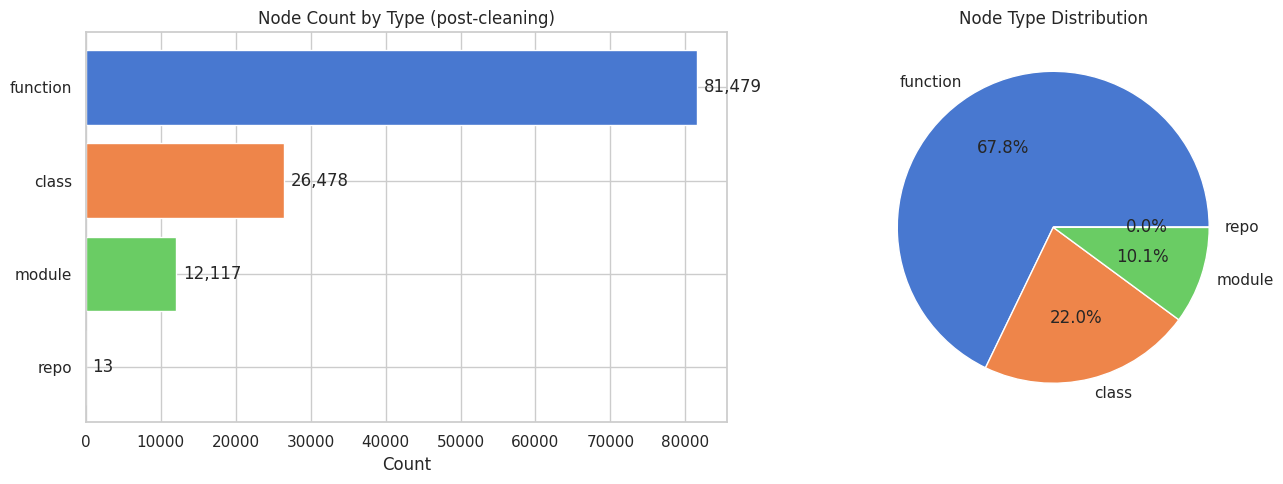

Total nodes: 120,087


In [9]:
# ── 5a. Node type distribution ──
node_type_counts = Counter(n["type"] for n in nodes)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
types_sorted = sorted(node_type_counts.items(), key=lambda x: -x[1])
types_df = pd.DataFrame(types_sorted, columns=["Node Type", "Count"])
ax = axes[0]
bars = ax.barh(types_df["Node Type"], types_df["Count"], color=sns.color_palette("muted", len(types_df)))
ax.set_xlabel("Count")
ax.set_title("Node Count by Type (post-cleaning)")
ax.bar_label(bars, fmt="{:,.0f}", padding=5)
ax.invert_yaxis()

# Pie chart
ax = axes[1]
ax.pie(types_df["Count"], labels=types_df["Node Type"], autopct="%1.1f%%",
       colors=sns.color_palette("muted", len(types_df)))
ax.set_title("Node Type Distribution")

plt.tight_layout()
plt.show()

print(f"Total nodes: {sum(node_type_counts.values()):,}")

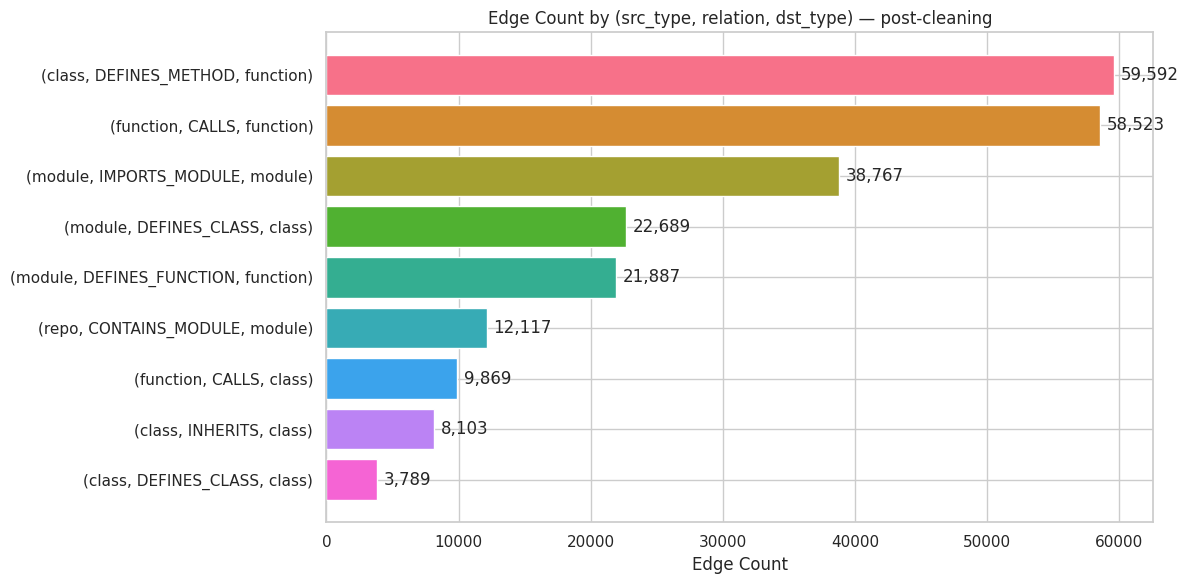

Total edges: 235,336
Edge types: 7  |  Triplet types: 9


In [10]:
# ── 5b. Edge type distribution ──
edge_type_counts = Counter(e["type"] for e in edges)

# Build full triplet counts using node type lookup
nid_to_type = {n["id"]: n["type"] for n in nodes}
triplet_counts = Counter()
for e in edges:
    src_type = nid_to_type[e["source"]]
    dst_type = nid_to_type[e["target"]]
    triplet_counts[(src_type, e["type"], dst_type)] += 1

fig, ax = plt.subplots(figsize=(12, 6))
triplets_sorted = sorted(triplet_counts.items(), key=lambda x: -x[1])
labels = [f"({s}, {r}, {d})" for (s, r, d), _ in triplets_sorted]
counts = [c for _, c in triplets_sorted]
bars = ax.barh(labels, counts, color=sns.color_palette("husl", len(labels)))
ax.set_xlabel("Edge Count")
ax.set_title("Edge Count by (src_type, relation, dst_type) — post-cleaning")
ax.bar_label(bars, fmt="{:,.0f}", padding=5)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"Total edges: {sum(edge_type_counts.values()):,}")
print(f"Edge types: {len(edge_type_counts)}  |  Triplet types: {len(triplet_counts)}")

In [11]:
# ── 5c. Scalar feature statistics per node type ──
node_types_present = {n["type"] for n in nodes}
for ntype in sorted(REQUIRED_SCALAR_FEATURES):
    if ntype not in node_types_present:
        continue
    type_nodes = [n for n in nodes if n["type"] == ntype]
    keys = REQUIRED_SCALAR_FEATURES[ntype]
    rows = [{k: n["features"].get(k, None) for k in keys} for n in type_nodes]
    df = pd.DataFrame(rows)
    print(f"\n{'─'*60}")
    print(f"  {ntype.upper()} — {len(type_nodes):,} nodes × {len(keys)} scalar features")
    print(f"{'─'*60}")
    display(df.describe().round(3))


────────────────────────────────────────────────────────────
  CLASS — 26,478 nodes × 16 scalar features
────────────────────────────────────────────────────────────


,num_methods,num_bases,inheritance_depth,num_decorators,docstring_length,num_class_vars,num_dunder_methods,line_span,in_degree,out_degree,pagerank,hub_score,authority_score
count,26478.000,26478.000,26478.000,26478.000,26478.000,26478.000,26478.000,26478.000,26478.000,26478.000,26478.000,26478.0,26478.0
mean,2.253,0.956,0.457,0.117,16.853,2.071,0.150,41.863,1.694,2.700,0.000,0.0,0.0
std,6.173,0.680,0.923,0.348,79.278,4.143,0.568,133.706,4.486,6.235,0.000,0.0,0.0
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,1.000,0.000,0.000,-0.0,0.0
25%,0.000,1.000,0.000,0.000,0.000,0.000,0.000,4.000,1.000,0.000,0.000,0.0,0.0
50%,0.000,1.000,0.000,0.000,0.000,1.000,0.000,12.000,1.000,1.000,0.000,-0.0,0.0
75%,2.000,1.000,1.000,0.000,0.000,3.000,0.000,35.000,1.000,3.000,0.000,-0.0,0.0
max,253.000,24.000,7.000,5.000,2871.000,209.000,20.000,6654.000,231.000,253.000,0.003,-0.0,0.0



────────────────────────────────────────────────────────────
  FUNCTION — 81,479 nodes × 31 scalar features
────────────────────────────────────────────────────────────


,num_params,num_defaults,type_hint_coverage,num_decorators,loc,body_stmt_count,docstring_length,num_local_vars,num_returns,num_yields,num_raises,nesting_depth,cyclomatic_complexity,num_calls_made,in_degree,out_degree,pagerank,hub_score,authority_score
count,81479.000,81479.000,81479.000,81479.000,81479.000,81479.000,81479.000,81479.000,81479.000,81479.000,81479.000,81479.000,81479.000,81479.000,81479.000,81479.000,81479.000,81479.0,81479.0
mean,1.231,0.121,0.051,0.262,16.700,6.957,20.344,2.620,0.479,0.009,0.071,0.514,2.467,5.975,1.939,1.065,0.000,0.0,0.0
std,1.920,0.625,0.208,0.562,20.788,8.130,75.354,3.624,0.871,0.170,0.398,0.906,3.212,6.826,25.363,1.441,0.000,0.0,0.0
min,0.000,0.000,0.000,0.000,1.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,1.000,0.000,0.000,-0.0,0.0
25%,0.000,0.000,0.000,0.000,5.000,2.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,2.000,1.000,0.000,0.000,0.0,0.0
50%,0.000,0.000,0.000,0.000,10.000,5.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,4.000,1.000,1.000,0.000,0.0,0.0
75%,2.000,0.000,0.000,0.000,21.000,9.000,0.000,4.000,1.000,0.000,0.000,1.000,3.000,8.000,1.000,1.000,0.000,0.0,0.0
max,156.000,24.000,1.000,9.000,629.000,263.000,4902.000,71.000,43.000,16.000,21.000,15.000,203.000,230.000,6489.000,31.000,0.023,0.0,0.0



────────────────────────────────────────────────────────────
  MODULE — 12,117 nodes × 12 scalar features
────────────────────────────────────────────────────────────


,num_imports,num_import_names,num_classes_defined,num_functions_defined,num_global_vars,docstring_length,import_fan_out,import_fan_in,pagerank,hub_score,authority_score
count,12117.000,12117.000,12117.000,12117.000,12117.000,12117.000,12117.000,12117.000,12117.000,12117.000,12117.000
mean,4.833,6.849,1.873,1.807,0.854,6.543,4.347,4.347,0.000,0.219,0.001
std,5.980,10.038,6.804,7.060,4.626,65.118,5.276,53.873,0.000,0.310,0.014
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-0.000,0.000
25%,1.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000
50%,3.000,3.000,1.000,0.000,0.000,0.000,3.000,0.000,0.000,0.040,0.000
75%,7.000,9.000,1.000,1.000,1.000,0.000,5.000,1.000,0.000,0.558,0.000
max,85.000,163.000,396.000,193.000,239.000,2728.000,77.000,3349.000,0.006,1.000,1.000



────────────────────────────────────────────────────────────
  REPO — 13 nodes × 9 scalar features
────────────────────────────────────────────────────────────


,num_files,num_modules,num_classes,num_functions,total_loc,num_packages,pagerank,hub_score,authority_score
count,13.000,13.000,13.000,13.000,13.000,13.0,13.0,13.0,13.0
mean,932.077,932.077,2036.769,6267.615,162766.846,1978.0,0.0,0.0,0.0
std,1286.618,1286.618,2609.026,9156.131,249728.941,0.0,0.0,0.0,0.0
min,39.000,39.000,58.000,267.000,5302.000,1978.0,0.0,-0.0,0.0
25%,55.000,55.000,215.000,715.000,11267.000,1978.0,0.0,0.0,0.0
50%,158.000,158.000,967.000,2741.000,43456.000,1978.0,0.0,0.0,0.0
75%,1247.000,1247.000,3184.000,5604.000,240276.000,1978.0,0.0,0.0,0.0
max,4207.000,4207.000,7889.000,29418.000,817792.000,1978.0,0.0,-0.0,0.0


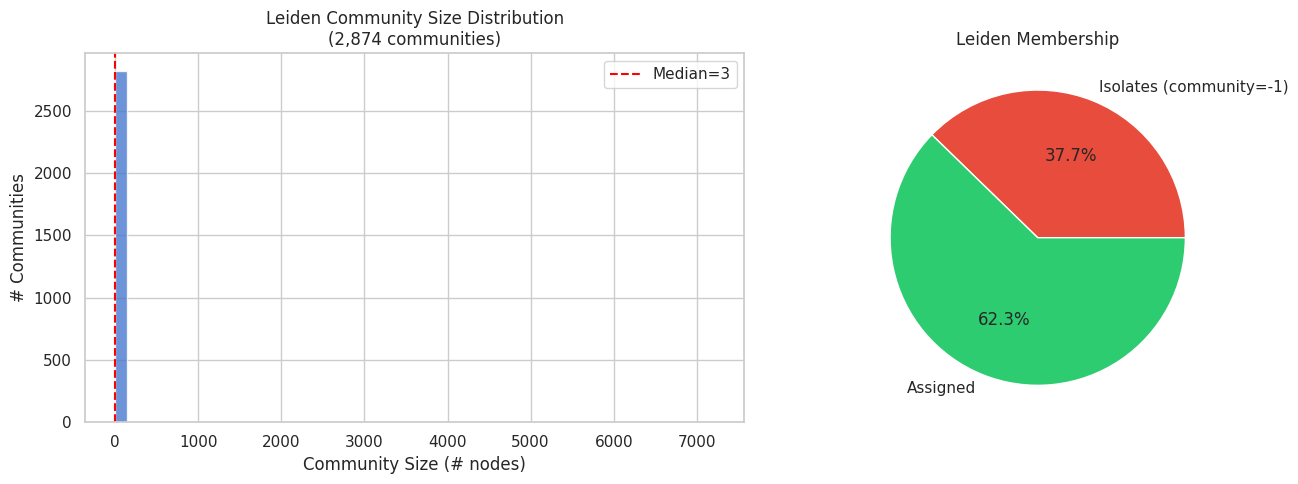

Communities: 2,874 | Isolates: 45,301 / 120,087 (37.7%)


In [12]:
# ── 5d. Leiden community distribution ──
leiden_ids = [n["features"].get("leiden_community", -1) for n in nodes]
leiden_series = pd.Series(leiden_ids, name="leiden_community")

n_isolates = int((leiden_series == -1).sum())
n_communities = leiden_series[leiden_series >= 0].nunique()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of community sizes (excluding isolates)
comm_sizes = leiden_series[leiden_series >= 0].value_counts()
ax = axes[0]
ax.hist(comm_sizes.values, bins=50, edgecolor="white", alpha=0.8)
ax.set_xlabel("Community Size (# nodes)")
ax.set_ylabel("# Communities")
ax.set_title(f"Leiden Community Size Distribution\n({n_communities:,} communities)")
ax.axvline(comm_sizes.median(), color="red", linestyle="--", label=f"Median={comm_sizes.median():.0f}")
ax.legend()

# Isolates vs. assigned
ax = axes[1]
ax.pie([n_isolates, len(nodes) - n_isolates],
       labels=["Isolates (community=-1)", "Assigned"],
       autopct="%1.1f%%", colors=["#e74c3c", "#2ecc71"])
ax.set_title("Leiden Membership")

plt.tight_layout()
plt.show()

print(f"Communities: {n_communities:,} | Isolates: {n_isolates:,} / {len(nodes):,} ({100*n_isolates/len(nodes):.1f}%)")

In [13]:
# ── 5e. embedding_input coverage ──
empty_counts = Counter()
total_counts = Counter()
sample_texts = {}
for n in nodes:
    ntype = n["type"]
    total_counts[ntype] += 1
    ei = n["features"].get("embedding_input", "")
    if not ei.strip():
        empty_counts[ntype] += 1
    elif ntype not in sample_texts:
        sample_texts[ntype] = ei[:120]

print("embedding_input coverage:")
print(f"  {'Type':>10s}  {'Total':>8s}  {'Empty':>8s}  {'Coverage':>10s}")
print(f"  {'─'*42}")
for ntype in sorted(total_counts):
    total = total_counts[ntype]
    empty = empty_counts.get(ntype, 0)
    pct = 100 * (total - empty) / total
    print(f"  {ntype:>10s}  {total:>8,}  {empty:>8,}  {pct:>9.2f}%")

print(f"\nSample embedding_input per type:")
for ntype, text in sorted(sample_texts.items()):
    print(f"  {ntype:>10s}: {text!r}...")

embedding_input coverage:
        Type     Total     Empty    Coverage
  ──────────────────────────────────────────
       class    26,478         0     100.00%
    function    81,479       316      99.61%
      module    12,117         0     100.00%
        repo        13         0     100.00%

Sample embedding_input per type:
       class: 'DefaultAccountAdapter | error_messages stash_verified_email unstash_verified_email is_email_verified can_delete_email fo'...
    function: 'def _delete_login_attempts_cached_email(self, request, **credentials):\n        cache_key = self._get_login_attempts_cach'...
      module: 'allauth'...
        repo: 'allauth'...


## 6. Sentence-Transformer Encoding

Encode each node's `embedding_input` string into a 384-dim vector using `all-MiniLM-L6-v2`.
- Results are cached to disk as `.pt` files (keyed by JSON path + node count)
- Empty `embedding_input` strings fall back to a qualname derived from the node ID

In [14]:
t0 = time.perf_counter()
text_embeddings = encode_texts(
    nodes,
    model_name=config.sentence_model,
    cache_dir=config.cache_dir,
    batch_size=config.text_encode_batch_size,
    json_path=config.json_path,
)
encoding_time = time.perf_counter() - t0

print(f"\nEncoding time: {encoding_time:.1f}s")
print(f"\nEmbedding shapes:")
for ntype, emb in sorted(text_embeddings.items()):
    print(f"  {ntype:>10s}: {emb.shape}  (dtype={emb.dtype})")

[text_encoder] 316 node(s) used ID-derived fallback text
[text_encoder] Loading sentence-transformer 'all-MiniLM-L6-v2' …


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

  function: torch.Size([81479, 384]) in 60.5s (1346 texts/s)
[text_encoder] Encoding 12,117 module texts …


Batches:   0%|          | 0/48 [00:00<?, ?it/s]

  module: torch.Size([12117, 384]) in 1.8s (6824 texts/s)
[text_encoder] Encoding 13 repo texts …


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

  repo: torch.Size([13, 384]) in 0.0s (270 texts/s)
[text_encoder] Embeddings cached to disk.

Encoding time: 89.7s

Embedding shapes:
       class: torch.Size([26478, 384])  (dtype=torch.float32)
    function: torch.Size([81479, 384])  (dtype=torch.float32)
      module: torch.Size([12117, 384])  (dtype=torch.float32)
        repo: torch.Size([13, 384])  (dtype=torch.float32)


## 7. Build HeteroData Graph

Assemble the PyG `HeteroData` object with:
- **Per-type scalar features** (`x_scalar`): normalized numeric/boolean features
- **Sentence embeddings** (`x_text`): 384-dim vectors from step 6
- **Leiden community IDs** (`leiden_ids`): integer IDs (−1 remapped to 0 as isolate bucket)
- **Edge indices** grouped by `(src_type, relation, dst_type)` triplet
- **Reverse edges** for semantic relations only (CALLS, INHERITS, IMPORTS_MODULE, DEFINES_*)

In [15]:
t0 = time.perf_counter()
data, node_index = build_hetero_data(nodes, edges, text_embeddings, config)
build_time = time.perf_counter() - t0

# Free raw data from memory
del text_embeddings

print(f"Build time: {build_time:.1f}s")
print(f"\nHeteroData object:")
print(f"  Node types : {len(data.node_types)} → {data.node_types}")
print(f"  Edge types : {len(data.edge_types)} (incl. reverse)")
print(f"  Num Leiden IDs: {config.num_leiden_ids:,}")
print(f"\nDerived input dims:")
for ntype in sorted(config.input_dims):
    print(f"  {ntype:>10s}: scalar={config.scalar_dims[ntype]}  +  text={config.sentence_dim}  +  leiden={config.leiden_embed_dim}  =  {config.input_dims[ntype]}")


  HETERO GRAPH SUMMARY

  Node counts by type:
         class:  26,478 nodes  |  scalar=16  text=384  leiden_emb=16  → total_input=416
      function:  81,479 nodes  |  scalar=31  text=384  leiden_emb=16  → total_input=431
        module:  12,117 nodes  |  scalar=12  text=384  leiden_emb=16  → total_input=412
          repo:      13 nodes  |  scalar=9  text=384  leiden_emb=16  → total_input=409
         TOTAL: 120,087

  Edge counts by (src_type, relation, dst_type):
                              (class, DEFINES_CLASS, class):   3,789
                          (class, DEFINES_METHOD, function):  59,592
                                   (class, INHERITS, class):   8,103
                                   (function, CALLS, class):   9,869
                                (function, CALLS, function):  58,523
                             (module, DEFINES_CLASS, class):  22,689
                       (module, DEFINES_FUNCTION, function):  21,887
                           (module, IMPORTS_

## 8. Train/Val Edge Split

Use `RandomLinkSplit` to split the supervised edge types (CALLS, INHERITS, IMPORTS_MODULE) into training and validation sets.
- 15% of edges held out for validation  
- 1:1 negative sampling ratio  
- Reverse edges are split in sync
- Non-supervised edges remain fully available for message passing

In [16]:
t0 = time.perf_counter()
train_data, val_data = split_edges(data, config)
split_time = time.perf_counter() - t0

print(f"Split time: {split_time:.1f}s")
print(f"\nTrain data edge types: {len(train_data.edge_types)}")
print(f"Val data edge types  : {len(val_data.edge_types)}")

[edge_split] Supervised triplets (4):
  ('class', 'INHERITS', 'class')  (8,103 edges) ↔ ('class', 'rev_INHERITS', 'class')
  ('module', 'IMPORTS_MODULE', 'module')  (38,767 edges) ↔ ('module', 'rev_IMPORTS_MODULE', 'module')
  ('function', 'CALLS', 'function')  (58,523 edges) ↔ ('function', 'rev_CALLS', 'function')
  ('function', 'CALLS', 'class')  (9,869 edges) ↔ ('class', 'rev_CALLS', 'function')

[edge_split] Edge split summary:
  Triplet                                                   Train+   Train-     Val+     Val-
  -------------------------------------------------------------------------------------
  (class, INHERITS, class)                                   6,888    6,888    1,215    1,215
  (module, IMPORTS_MODULE, module)                          32,952   32,952    5,815    5,815
  (function, CALLS, function)                               49,745   49,745    8,778    8,778
  (function, CALLS, class)                                   8,389    8,389    1,480    1,480

Split

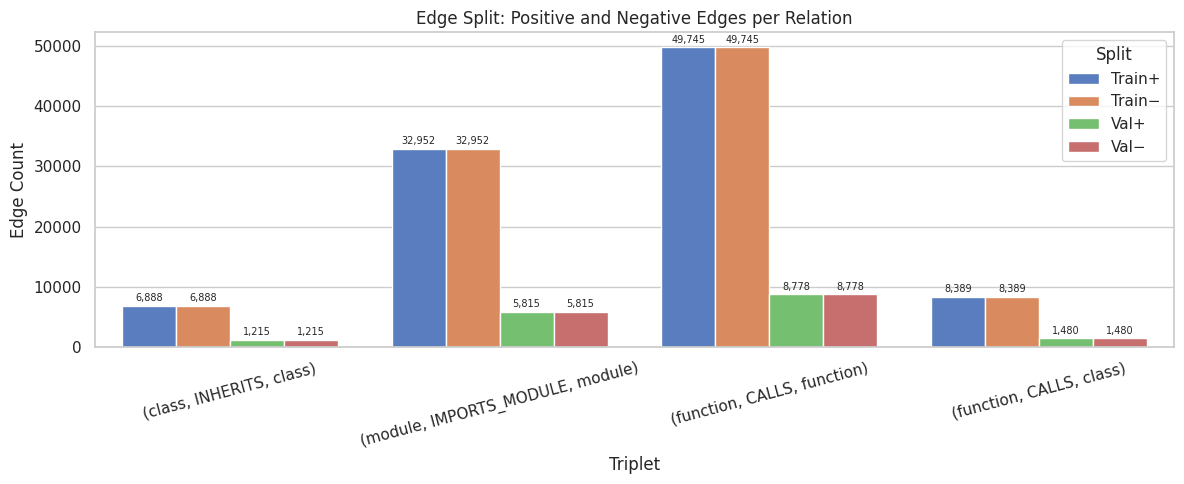

In [17]:
# ── Visualize split distribution ──
supervised_triplets = [
    t for t in train_data.edge_types
    if t[1] in config.supervised_relations
    and hasattr(train_data[t], "edge_label_index")
]

split_rows = []
for triplet in supervised_triplets:
    train_labels = train_data[triplet].edge_label
    val_labels = val_data[triplet].edge_label
    label = f"({triplet[0]}, {triplet[1]}, {triplet[2]})"
    split_rows.append({"Triplet": label, "Split": "Train+", "Count": int((train_labels == 1).sum())})
    split_rows.append({"Triplet": label, "Split": "Train−", "Count": int((train_labels == 0).sum())})
    split_rows.append({"Triplet": label, "Split": "Val+",   "Count": int((val_labels == 1).sum())})
    split_rows.append({"Triplet": label, "Split": "Val−",   "Count": int((val_labels == 0).sum())})

split_df = pd.DataFrame(split_rows)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=split_df, x="Triplet", y="Count", hue="Split", ax=ax)
ax.set_title("Edge Split: Positive and Negative Edges per Relation")
ax.set_ylabel("Edge Count")
ax.tick_params(axis="x", rotation=15)
ax.legend(title="Split")
for container in ax.containers:
    ax.bar_label(container, fmt="{:,.0f}", fontsize=7, padding=2)
plt.tight_layout()
plt.show()

## 9. Save Preprocessed Artifacts

Save everything the training and evaluation notebooks need:
- `train_data.pt` / `val_data.pt` — PyG HeteroData objects
- `node_index.json` — string-ID ↔ integer-index mapping per type
- `config.pt` — serialized RGATConfig for reproducibility

In [18]:
# Save HeteroData objects
torch.save(train_data, ARTIFACTS_DIR / "train_data.pt")
torch.save(val_data,   ARTIFACTS_DIR / "val_data.pt")
print(f"✓ Saved train_data.pt  ({os.path.getsize(ARTIFACTS_DIR / 'train_data.pt') / 1e6:.1f} MB)")
print(f"✓ Saved val_data.pt    ({os.path.getsize(ARTIFACTS_DIR / 'val_data.pt') / 1e6:.1f} MB)")

# Save node index mapping
import json as _json
with open(ARTIFACTS_DIR / "node_index.json", "w") as f:
    _json.dump(node_index, f)
print(f"✓ Saved node_index.json ({sum(len(v) for v in node_index.values()):,} entries)")

# Save config (as dict via torch.save for simplicity)
import dataclasses
config_dict = dataclasses.asdict(config)
torch.save(config_dict, ARTIFACTS_DIR / "config.pt")
print(f"✓ Saved config.pt")

print(f"\nAll artifacts saved to: {ARTIFACTS_DIR}")

✓ Saved train_data.pt  (210.7 MB)
✓ Saved val_data.pt    (207.5 MB)
✓ Saved node_index.json (120,087 entries)
✓ Saved config.pt

All artifacts saved to: /content/rgat_project/artifacts


## Summary

| Stage | Description |
|-------|-------------|
| Load JSON | Structural validation of 132K nodes, 280K edges |
| Schema | Per-type feature completeness, type checks |
| **Data Cleaning** | **Collapse file nodes, remove empty `__init__` hubs, fix self-loops, cap CALLS degree → 120K nodes, 235K edges** |
| Text Encoding | 384-dim sentence embeddings via all-MiniLM-L6-v2 |
| Graph Build | HeteroData with 4 node types, 17 edge types (selective reverse) |
| Edge Split | 4 supervised triplets split 85/15, 1:1 neg sampling |

**Next** → Open `02_training.ipynb` to build and train the RGAT model.